## 1. Environment Setup and Directory Initialization
Before starting the analysis, we define the base project path and establish a dedicated directory for saving generated figures. This ensures that all outputs are organized and that the script remains compatible across different local environments by using absolute paths.

Objective: Set up a consistent file structure for the project.

Key Action: Create a /figures directory if it does not already exist.

In [25]:
import os

# Retrieve the absolute path of the current working directory
# In a Jupyter environment, this points to the folder containing the .ipynb file
base_path = os.getcwd()

# Define and create a 'figures' directory to store analysis plots
# 'exist_ok=True' ensures no error is thrown if the directory already exists
figures_path = os.path.join(base_path, "figures")
os.makedirs(figures_path, exist_ok=True)

print(f"Current project base path: {base_path}")
print(f"Figures directory initialized at: {figures_path}")

Current project base path: /Users/qgroup/Desktop/final_draft
Figures directory initialized at: /Users/qgroup/Desktop/final_draft/figures


## 2. Story-level Correlation Analysis of Narrative Signals

This section implements a statistical pipeline to measure the relationships between three narrative dimensions: **Surprisal, Coherence, and Semantic Shift**. Following the methodology of Sap et al. (2022), we calculate pairwise Pearson correlations for each story to assess linear dependence and signal redundancy.

### Analysis Workflow:
1. **Data Parsing:** Convert string-formatted sequences (from CSV) into numerical arrays.
2. **Length Alignment:** Synchronize the lengths of the three signal sequences.
3. **Filtering:** Exclude stories with fewer than three sentences to maintain statistical reliability.
4. **Correlation Calculation:** - Compute Pearson's $r$ for Surprisal-Coherence, Surprisal-Semantic, and Coherence-Semantic.
    - Handle edge cases where standard deviation is zero to prevent calculation errors.
5. **Distribution Summary:** The results allow for examining corpus-wide distributions (mean, SD, quartiles) of these narrative interactions.

In [26]:
import pandas as pd
import numpy as np
import ast
from scipy.stats import pearsonr
import os

def safe_to_list(x):
    """
    Converts string representations of lists into actual Python list objects.
    Returns an empty list if parsing fails or input is invalid.
    """
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

def main():
    # 1. Path Configuration and Data Loading
    base_path = "."
    input_file = f"{base_path}/short_novel_with_surprisal_coherence_semantic.csv"
    output_file = f"{base_path}/short_novel_with_correlations.csv"

    if not os.path.exists(input_file):
        print(f"Error: File not found: {input_file}")
        return

    df = pd.read_csv(input_file)

    # 2. Automated Detection of Narrative Signal Columns
    # Identifies columns related to surprisal, coherence, and semantic shift 
    # based on naming patterns.
    col_map = {}
    for col in df.columns:
        if "surprisal" in col and ("vector" in col or "list" in col):
            col_map["surprisal"] = col
        if "coherence" in col and ("vector" in col or "list" in col):
            col_map["coherence"] = col
        if ("semantic_shift" in col or "topic_shift" in col) and ("vector" in col or "list" in col):
            col_map["semantic"] = col

    # 3. Pairwise Correlation Calculation
    corr_sc, corr_sm, corr_cm = [], [], []

    for _, row in df.iterrows():
        # Parse list-like strings into numpy arrays
        s = np.array(safe_to_list(row[col_map["surprisal"]]), dtype=float)
        c = np.array(safe_to_list(row[col_map["coherence"]]), dtype=float)
        m = np.array(safe_to_list(row[col_map["semantic"]]), dtype=float)
        
        # Align lengths based on the shortest signal sequence
        min_len = min(len(s), len(c), len(m))
        
        # Exclude stories with fewer than 3 sentences for statistical significance
        if min_len < 3:
            corr_sc.append(np.nan); corr_sm.append(np.nan); corr_cm.append(np.nan)
            continue
            
        s, c, m = s[:min_len], c[:min_len], m[:min_len]
        
        # Internal helper to handle Pearson correlation with zero-variance edge cases
        def get_r(a, b):
            if np.std(a) == 0 or np.std(b) == 0:
                return 0.0
            return pearsonr(a, b)[0]

        # Calculate correlations for each pair: Surp-Coh, Surp-Sem, Coh-Sem
        corr_sc.append(get_r(s, c))
        corr_sm.append(get_r(s, m))
        corr_cm.append(get_r(c, m))

    # 4. Data Integration and Output
    # Store the resulting coefficients back into the dataframe
    df["corr_surp_coh"] = corr_sc
    df["corr_surp_sem"] = corr_sm
    df["corr_coh_sem"] = corr_cm

    # Save the processed dataset with UTF-8-BOM encoding for compatibility
    df.to_csv(output_file, index=False, encoding="utf-8-sig")
    print(f"Calculation complete. Correlation coefficients saved to: {output_file}")

if __name__ == "__main__":
    main()

Calculation complete. Correlation coefficients saved to: ./short_novel_with_correlations.csv


## 3. Signal Preprocessing: Normalization, Smoothing, and Burn-in Diagnostic

To facilitate comparison across stories of varying lengths, we transform raw narrative signals into a standardized format. This process involves resampling, smoothing, and identifying initial "burn-in" artifacts to ensure the stability of subsequent structural analysis.

### Key Methodologies:
1. **Length Normalization (Resampling):** Each signal is resampled onto a fixed grid of $L=50$ equidistant positions. This meso-scale representation ($L=50$) preserves structural shape while mitigating high-frequency noise.
2. **Gaussian Smoothing:** A 1D Gaussian filter ($\sigma=2$) is applied to emphasize broad narrative tendencies and further attenuate sentence-level volatility.
3. **Statistical Feature Extraction:** We compute story-level descriptors (mean, standard deviation, peak position, and regional means) to capture the overall profile of each signal.
4. **Z-score Normalization:** Signals are standardized per-story to express values relative to the story-specific mean and variance.
5. **Burn-in Diagnostic:** We analyze the global variance of surprisal across the 50 bins to detect the "elbow" point. This allows us to separate initial processing artifacts (unconditioned model state) from the stable narrative regime.

In [27]:
import pandas as pd
import numpy as np
import ast
import os
from scipy.ndimage import gaussian_filter1d

# ==========================================
# 1. Configuration: Paths and Constants
# ==========================================
base_path = "." 
input_file = f"{base_path}/short_novel_with_surprisal_coherence_semantic.csv"
output_curves_file = f"{base_path}/short_novel_with_all_curves_50.csv"
output_feat_file = f"{base_path}/short_novel_with_all_features_50.csv"

# Fixed grid length for normalization
L = 50 

# ==========================================
# 2. Utility Functions
# ==========================================
def safe_to_list(x):
    """Parses various input types into a Python list of floats."""
    if isinstance(x, (list, tuple)):
        return list(x)
    if not isinstance(x, str) or not x.strip():
        return []
    try:
        v = ast.literal_eval(x)
        if isinstance(v, (list, tuple)):
            return list(v)
        return []
    except Exception:
        return []

def resample_curve(values, L=50):
    """Resamples a sequence to a fixed length L using linear interpolation."""
    values = safe_to_list(values)
    if not values:
        return [np.nan] * L
    arr = np.array(values, dtype=float)
    T = len(arr)
    if T <= 1:
        return [float(arr[0]) if T == 1 else np.nan] * L
    
    x_orig = np.linspace(0.0, 1.0, T)
    x_new = np.linspace(0.0, 1.0, L)
    interpolated = np.interp(x_new, x_orig, arr)
    return [round(x, 4) for x in interpolated.tolist()]

def smooth_curve(values, sigma=2):
    """Applies 1D Gaussian smoothing to the input signal."""
    arr = np.array(values, dtype=float)
    if len(arr) == 0 or np.all(np.isnan(arr)):
        return arr.tolist()
    smoothed = gaussian_filter1d(arr, sigma=sigma)
    return [round(x, 4) for x in smoothed.tolist()]

def curve_features(values):
    """Extracts statistical and positional descriptors from the narrative signal."""
    values = safe_to_list(values)
    if not values:
        return {
            "len_sents": 0, "mean": np.nan, "std": np.nan, "max_val": np.nan,
            "max_pos_rel": np.nan, "mean_begin": np.nan, "mean_middle": np.nan, "mean_end": np.nan,
        }
    arr = np.array(values, dtype=float)
    T = len(arr)
    mean = float(arr.mean()) if T > 0 else np.nan
    std = float(arr.std()) if T > 0 else np.nan
    max_val = float(arr.max()) if T > 0 else np.nan
    argmax = int(arr.argmax()) if T > 0 else 0
    max_pos_rel = argmax / (T - 1) if T > 1 else 0
    
    # Divide the narrative into three equal segments: Beginning, Middle, End
    b_end = max(1, T // 3)
    m_end = max(b_end + 1, 2 * T // 3)
    begin = float(arr[:b_end].mean()) if b_end > 0 else np.nan
    middle = float(arr[b_end:m_end].mean()) if m_end > b_end else np.nan
    end = float(arr[m_end:].mean()) if T > m_end else np.nan
    
    return {
        "len_sents": T, "mean": mean, "std": std, "max_val": max_val,
        "max_pos_rel": max_pos_rel, "mean_begin": begin, "mean_middle": middle, "mean_end": end,
    }

# ==========================================
# 3. Execution: Data Processing
# ==========================================
if not os.path.exists(input_file):
    print(f"Error: File not found: {input_file}")
else:
    df = pd.read_csv(input_file)
    print(f"Total stories loaded: {len(df)}")

    # 4. Vector Cleaning
    # Synchronize column naming for surprisal, coherence, and semantic shift
    df["surprisal_list"] = df.get("surprisal_vector", df.get("surprisal_list", "[]")).apply(safe_to_list)
    df["coherence_list"] = df.get("coherence_vector", df.get("coherence_list", "[]")).apply(safe_to_list)
    df["semantic_shift_list"] = df.get("semantic_shift_vector", df.get("semantic_shift_list", "[]")).apply(safe_to_list)

    # 5. Curve Generation (Normalization & Smoothing)
    print("Generating 50-bin curves...")
    for col in ["surprisal", "coherence", "semantic_shift"]:
        raw_list_col = f"{col}_list"
        df[f"{col}_curve_50_raw"] = df[raw_list_col].apply(lambda v: resample_curve(v, L=L))
        df[f"{col}_curve_50_smooth"] = df[f"{col}_curve_50_raw"].apply(lambda v: smooth_curve(v, sigma=2))

    df.to_csv(output_curves_file, index=False, encoding="utf-8-sig")

    # 6. Statistical Feature Extraction
    print("Extracting story-level statistical features...")
    surp_feat = df["surprisal_list"].apply(curve_features).apply(pd.Series).add_prefix("surp_")
    coh_feat = df["coherence_list"].apply(curve_features).apply(pd.Series).add_prefix("coh_")
    sem_feat = df["semantic_shift_list"].apply(curve_features).apply(pd.Series).add_prefix("sem_")

    df_feat = pd.concat([df, surp_feat, coh_feat, sem_feat], axis=1)
    df_feat.to_csv(output_feat_file, index=False, encoding="utf-8-sig")
    print("Processing complete. Files saved.")

Total stories loaded: 2636
Generating 50-bin curves...
Extracting story-level statistical features...
Processing complete. Files saved.



Bin Index  | Variance   | % Drop
-----------------------------------
Bin 0         | 1.5555     | -
Bin 1         | 1.1644     | 25.1%
Bin 2         | 0.8186     | 29.7%
Bin 3         | 0.7137     | 12.8%
Bin 4         | 0.7313     | -2.5%
Bin 5         | 0.7581     | -3.7%
Bin 6         | 0.7663     | -1.1%
Bin 7         | 0.7647     | 0.2%
Bin 8         | 0.7694     | -0.6%
Bin 9         | 0.7838     | -1.9%


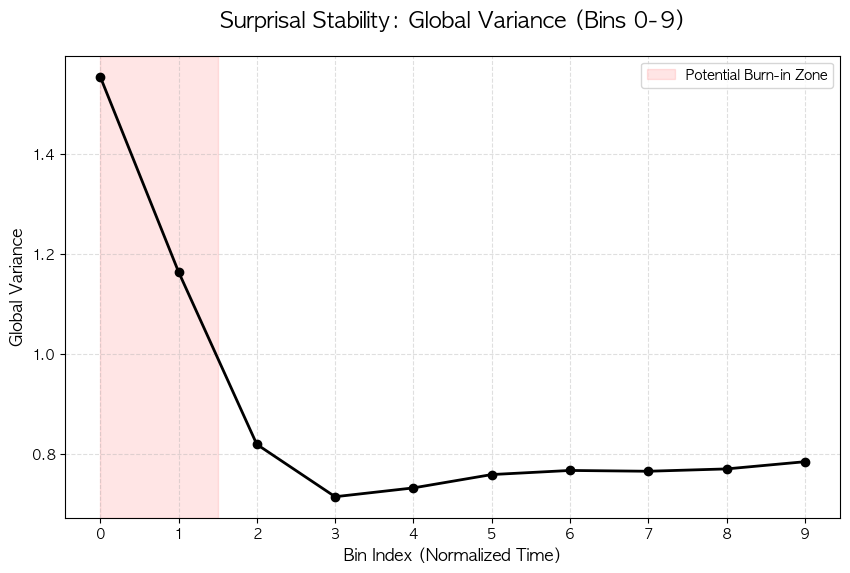

In [28]:
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt

def safe_to_list(x):
    """Safely converts string representations of lists back to Python objects."""
    if isinstance(x, (list, tuple)): return list(x)
    try: return list(ast.literal_eval(x))
    except: return []

def main():
    base_path = "."
    input_file = f"{base_path}/short_novel_with_all_curves_50.csv"
    
    if not os.path.exists(input_file):
        print("Error: Please run the preprocessing script (Code Cell 1) first.")
        return

    df = pd.read_csv(input_file)
    
    # 1. Z-score Normalization across Preprocessed Curves
    # Use smoothed 50-bin surprisal curves for stability analysis
    curves = df["surprisal_curve_50_smooth"].apply(safe_to_list)
    
    processed_curves = []
    for c in curves:
        if len(c) == 50:
            arr = np.array(c)
            # Apply per-story Z-score normalization to focus on dispersion
            std_val = np.std(arr)
            if std_val > 0:
                processed_curves.append((arr - np.mean(arr)) / std_val)

    # Stack curves to compute global variance at each of the 50 positions
    X = np.vstack(processed_curves)
    global_vars = np.var(X, axis=0)

    # 2. Burn-in Zone Analysis (Inspection of the first 10 bins)
    limit = 10 
    indices = np.arange(limit)
    vars_to_show = global_vars[:limit]

    print(f"\n{'Bin Index':<10} | {'Variance':<10} | {'% Drop'}")
    print("-" * 35)
    for i, v in enumerate(vars_to_show):
        drop = f"{(vars_to_show[i-1]-v)/vars_to_show[i-1]*100:.1f}%" if i > 0 else "-"
        print(f"Bin {i:<9} | {v:<10.4f} | {drop}")

    # 3. Visualization of Stability Diagnostic
    plt.figure(figsize=(10, 6))
    # Highlight potential burn-in zone based on variance elbow
    plt.axvspan(0, 1.5, color='red', alpha=0.1, label='Potential Burn-in Zone')
    plt.plot(indices, vars_to_show, marker='o', color='black', linewidth=2)
    
    plt.title("Surprisal Stability: Global Variance (Bins 0-9)", fontsize=16, pad=20)
    plt.xlabel("Bin Index (Normalized Time)", fontsize=12)
    plt.ylabel("Global Variance", fontsize=12)
    plt.xticks(indices)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    
    # Export the diagnostic figure for research documentation
    os.makedirs(f"{base_path}/figures", exist_ok=True)
    plt.savefig(f"{base_path}/figures/burn_in_diagnostic_0_9.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    main()

## 4. Surprisal-based Trajectory Clustering and Validation

This section identifies archetypal narrative structures by clustering surprisal trajectories. To eliminate initialization artifacts, we focus on the **stable narrative region (Bins 2–49)**. The process involves determining the optimal number of clusters, validating clustering stability, and confirming the statistical distinctiveness of the resulting archetypes.

### Analysis Workflow:
1.  **Data Preprocessing:** Extract the stable region and apply $z$-standardization to focus on the relative shape of narrative arcs rather than absolute magnitude.
2.  **Optimal K Selection:** Use **Inertia (Elbow Method)** and **Silhouette Scores** to identify the most natural grouping ($k$).
3.  **Clustering Stability:** Validate robustness using the **Adjusted Rand Index (ARI)** across multiple random seeds.
4.  **Structural Descriptors:** Extract shape-based features (peak timing, intensity, frequency, and volatility) to characterize each cluster.
5.  **Statistical Validation:** Conduct **ANOVA** and **Kruskal-Wallis** tests to verify that identified archetypes represent statistically separate populations.
6.  **Archetype Profiling:** Model the spatial concentration of narrative climaxes using **Kernel Density Estimation (KDE)**.

Step 1: Loading data and performing Z-score normalization...
Step 2: Searching for optimal number of clusters (K)...
=> Optimal K detected: 5


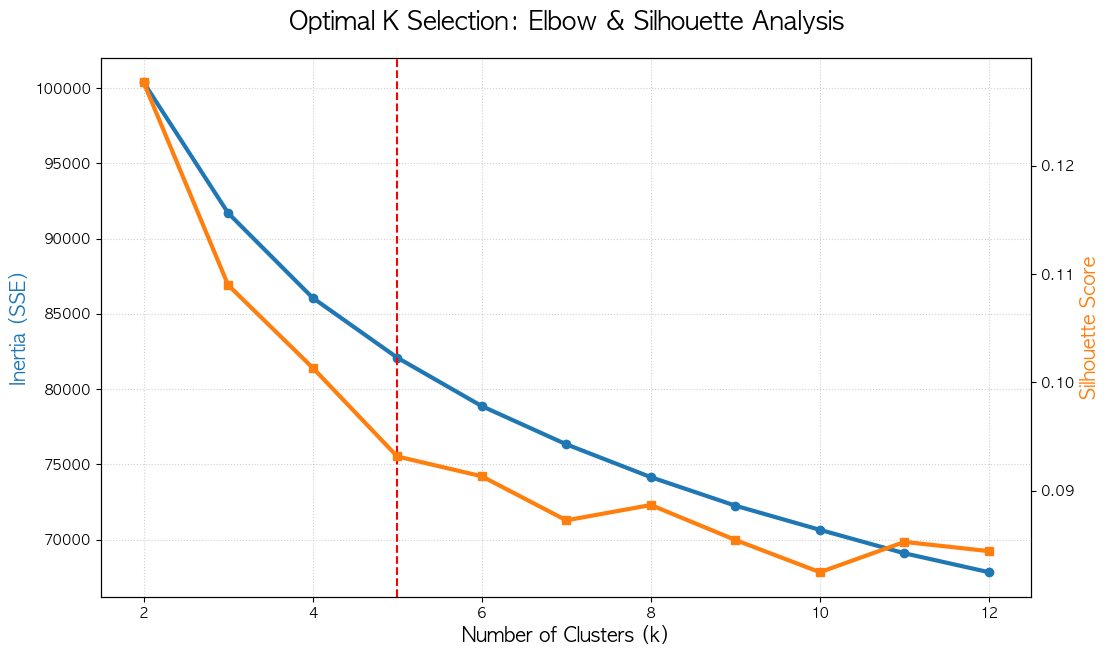

Step 3: Performing K-means clustering (K=5) and ARI validation...
★ Mean ARI: 0.8164 (High stability confirmed)
Step 4: Computing structural descriptors for statistical validation...
Step 5: Conducting ANOVA and Kruskal-Wallis tests...

=== Statistical Validation Results ===
           Variable      F-stat        p_anova      H-stat           p_kw
0    surp_peak_pos  202.090449  2.654411e-151  476.730592  7.216530e-102
1     surp_max_val   50.798080   3.001644e-41  159.284913   2.081059e-33
2          n_peaks   29.799014   2.815971e-24  106.233542   4.623930e-22
3  surp_std_stable    0.522287   7.193729e-01    2.683632   6.120818e-01
Step 6: Profiling peak distributions per archetype...

=== Archetype Structural Summary ===
               n_stories  avg_peaks  multi_peak_ratio
cluster_surp                                        
0                   451      1.530            49.002
1                   563      1.149            32.327
2                   449      1.528            48.107


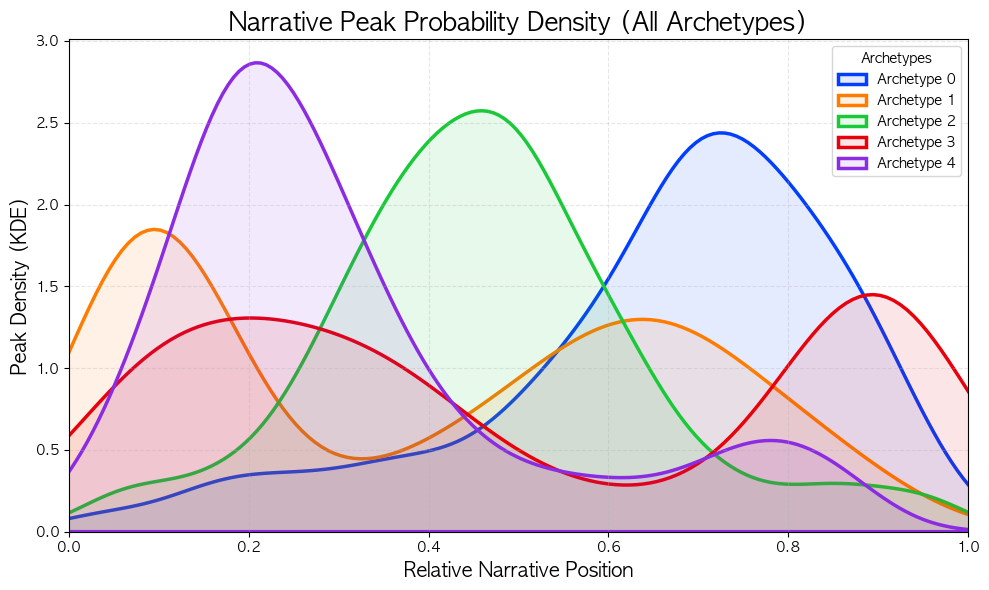

Analysis complete. All stats and figures have been saved.


In [29]:
import os
import pandas as pd
import numpy as np
import ast
import platform
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from scipy.stats import zscore, f_oneway, kruskal, gaussian_kde
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator

# ==========================================
# 0. Environment Setup: Fonts and Paths
# ==========================================
def set_korean_font():
    """Sets appropriate Korean fonts for plotting based on the OS."""
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()
base_path = "." 
os.makedirs(f"{base_path}/figures", exist_ok=True)

# ==========================================
# 1. Data Loading and Stable Region Extraction
# ==========================================
print("Step 1: Loading data and performing Z-score normalization...")
df = pd.read_csv(f"{base_path}/short_novel_with_all_curves_50.csv")

def safe_vec(x):
    """Safely converts string representations to list objects."""
    try: return list(ast.literal_eval(x))
    except: return []

df["surp_curve"] = df["surprisal_curve_50_smooth"].apply(safe_vec)
# Filter stories with valid lengths and reset index
df = df[df["surp_curve"].map(len) == 50].reset_index(drop=True)

# Extract stable region (Bins 2-49) and apply Z-score normalization
# This removes 'burn-in' noise and focuses on the narrative trajectory shape
X_raw_stable = np.vstack(df["surp_curve"].values)[:, 2:] 
X_scaled = np.nan_to_num(zscore(X_raw_stable, axis=1))

# ==========================================
# 2. Optimal K Exploration (Elbow & Silhouette)
# ==========================================
print("Step 2: Searching for optimal number of clusters (K)...")
ks = range(2, 13)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Automatically detect the 'elbow' point
best_k = KneeLocator(ks, inertias, curve='convex', direction='decreasing').knee or 5
print(f"=> Optimal K detected: {best_k}")

# Visualization: Elbow and Silhouette Analysis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.set_xlabel('Number of Clusters (k)', fontsize=14)
ax1.set_ylabel('Inertia (SSE)', color='tab:blue', fontsize=14)
ax1.plot(ks, inertias, marker='o', color='tab:blue', linewidth=3, label='Inertia')
ax1.axvline(x=best_k, color='red', linestyle='--', label=f'Optimal K={best_k}')

ax2 = ax1.twinx()  
ax2.set_ylabel('Silhouette Score', color='tab:orange', fontsize=14)
ax2.plot(ks, silhouettes, marker='s', color='tab:orange', linewidth=3, label='Silhouette')

plt.title('Optimal K Selection: Elbow & Silhouette Analysis', fontsize=18, pad=20)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.savefig(f"{base_path}/figures/optimal_k_validation.png", dpi=300)
plt.show()

# ==========================================
# 3. Clustering and Robustness Check (ARI)
# ==========================================
print(f"Step 3: Performing K-means clustering (K={best_k}) and ARI validation...")
base_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df["cluster_surp"] = base_kmeans.fit_predict(X_scaled)

# Check label stability across different random seeds using Adjusted Rand Index (ARI)
ari_list = [adjusted_rand_score(df["cluster_surp"], 
            KMeans(n_clusters=best_k, random_state=s, n_init=20).fit_predict(X_scaled)) 
            for s in range(10, 20)]

print(f"★ Mean ARI: {np.mean(ari_list):.4f} (High stability confirmed)")

# ==========================================
# 4. Feature Extraction: Shape Descriptors
# ==========================================
print("Step 4: Computing structural descriptors for statistical validation...")
# Relative position of the primary peak
df["surp_peak_pos"] = (X_scaled.argmax(axis=1)) / (X_scaled.shape[1] - 1)
# Maximum intensity (Z-score)
df["surp_max_val"] = X_scaled.max(axis=1)
# Number of peaks exceeding Z > 1.0
df["n_peaks"] = [len(find_peaks(row, height=1.0)[0]) for row in X_scaled]
# Volatility within the stable region
df["surp_std_stable"] = X_scaled.std(axis=1)

# ==========================================
# 5. Statistical Significance Testing
# ==========================================
print("Step 5: Conducting ANOVA and Kruskal-Wallis tests...")
descriptors = ["surp_peak_pos", "surp_max_val", "n_peaks", "surp_std_stable"]
test_results = []

for var in descriptors:
    groups = [df[df["cluster_surp"] == k][var] for k in range(best_k)]
    f_val, p_anova = f_oneway(*groups)
    h_val, p_kw = kruskal(*groups)
    test_results.append({"Variable": var, "F-stat": f_val, "p_anova": p_anova, "H-stat": h_val, "p_kw": p_kw})

results_table = pd.DataFrame(test_results)
print("\n=== Statistical Validation Results ===\n", results_table)

# ==========================================
# 6. Archetype Profiling: Peak Distribution
# ==========================================
print("Step 6: Profiling peak distributions per archetype...")
# Frequency of stories with N peaks within each cluster
peak_dist = pd.crosstab(df["cluster_surp"], df["n_peaks"], normalize='index') * 100
peak_dist.columns = [f"{int(c)} Peaks" for c in peak_dist.columns]

archetype_summary = df.groupby("cluster_surp").agg(
    n_stories=("cluster_surp", "size"),
    avg_peaks=("n_peaks", "mean"),
    multi_peak_ratio=("n_peaks", lambda x: (x >= 2).sum() / len(x) * 100)
).round(3)

print("\n=== Archetype Structural Summary ===\n", archetype_summary)

# ==========================================
# 7. Visualization: Peak Density Estimation (KDE)
# ==========================================
print("Step 7: Generating Kernel Density Estimation plots for narrative climaxes...")

# Collect all peak positions for KDE
peak_list = []
for i in range(len(X_scaled)):
    peaks, _ = find_peaks(X_scaled[i], height=1.0)
    for p in peaks:
        peak_list.append({
            "cluster": df.loc[i, "cluster_surp"], 
            "peak_pos": p / (X_scaled.shape[1] - 1)
        })

df_peaks = pd.DataFrame(peak_list)
colors = sns.color_palette("bright", best_k)

# [A] Global Comparison KDE

plt.figure(figsize=(10, 6))
for k in range(best_k):
    subset_peaks = df_peaks[df_peaks["cluster"] == k]
    if not subset_peaks.empty:
        sns.kdeplot(data=subset_peaks, x="peak_pos", color=colors[k], 
                    fill=True, alpha=0.1, linewidth=2.5, label=f"Archetype {k}")

plt.title("Narrative Peak Probability Density (All Archetypes)", fontsize=18)
plt.xlabel("Relative Narrative Position", fontsize=14)
plt.ylabel("Peak Density (KDE)", fontsize=14)
plt.xlim(0, 1)
plt.legend(title="Archetypes")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{base_path}/figures/all_clusters_comparison_kde.png", dpi=300)
plt.show()

# [B] Export Individual Archetype Profiles with Mode Detection
for k in range(best_k):
    subset_peaks = df_peaks[df_peaks["cluster"] == k]
    if len(subset_peaks) > 1:
        plt.figure(figsize=(8, 5))
        sns.kdeplot(data=subset_peaks, x="peak_pos", color=colors[k], fill=True, alpha=0.4)
        
        # Numeric mode detection
        x_range = np.linspace(0, 1, 1000)
        kde_function = gaussian_kde(subset_peaks["peak_pos"])
        y_values = kde_function(x_range)
        mode_x = x_range[np.argmax(y_values)]
        
        plt.axvline(x=mode_x, color=colors[k], linestyle='--', label=f'Mode: {mode_x:.2f}')
        plt.title(f"Archetype {k}: Peak Density Profile", fontsize=16)
        plt.legend()
        plt.savefig(f"{base_path}/figures/cluster_{k}_detail.png", dpi=300)
        plt.close()

# Save final master dataset
df.drop(columns=['surp_curve']).to_csv(f"{base_path}/short_novel_clustered_surprisal_stable.csv", index=False, encoding='utf-8-sig')
print("Analysis complete. All stats and figures have been saved.")

## 5. Characterizing Archetypal Narrative Arcs

After validating the clusters, we analyze the narrative patterns of each archetype through a multi-layered approach.

### Analysis Dimensions:
1. **Master Curves:** A representative "master curve" is calculated for each cluster using the bin-wise arithmetic mean of all trajectories.
2. **Prototypical Narratives:** We identify "prototypes"—individual stories whose trajectories are closest to the cluster centroid in terms of Euclidean distance. 
3. **Qualitative Inspection (Copyright Note):** - Due to copyright restrictions, the actual text content (`sentence_list`) and its derived metadata (e.g., `surp_len_sents`) have been excluded from this script.
    - The filtering logic based on sentence count has been disabled, and the prototype selection now relies on the structural integrity of the resampled curves.

Loading data: ./short_novel_clustered_surprisal_stable.csv

Extracting Prototypical Narratives per Archetype

[Archetype 0]
  Rank 1: Overcoming COVID-44 (ISBN: 9791192333014)
  Rank 2: Infiltration (ISBN: 9791163472896)
  Rank 3: Laughter Injection (ISBN: 9791197603655)


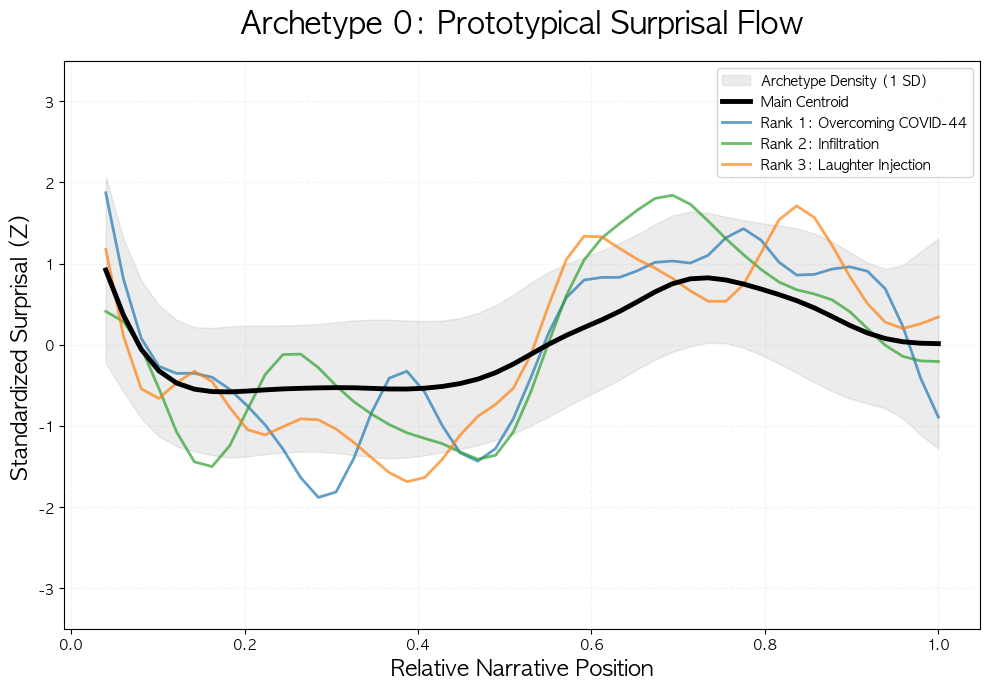


[Archetype 1]
  Rank 1: God's Shoes (ISBN: 9788954629386)
  Rank 2: Momo-nim (ISBN: 9791197103803)
  Rank 3: A Certain Graduation (ISBN: 9788960907706)


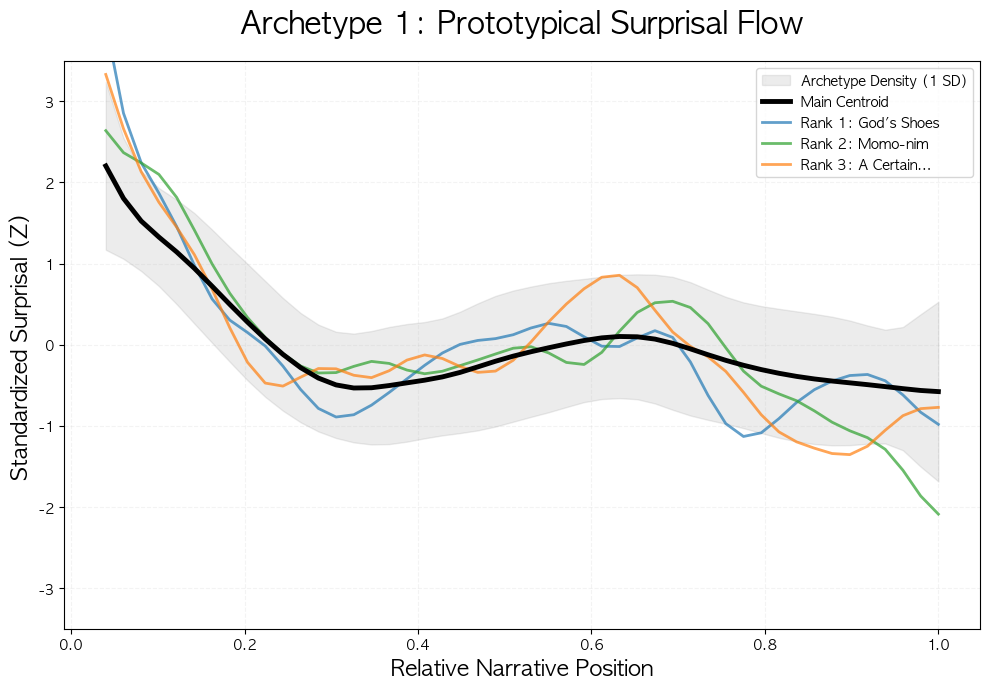


[Archetype 2]
  Rank 1: Friday (ISBN: 9791167374462)
  Rank 2: Run, Son (ISBN: 9788960902572)
  Rank 3: Byeokryeon Port... (ISBN: 9791168611092)


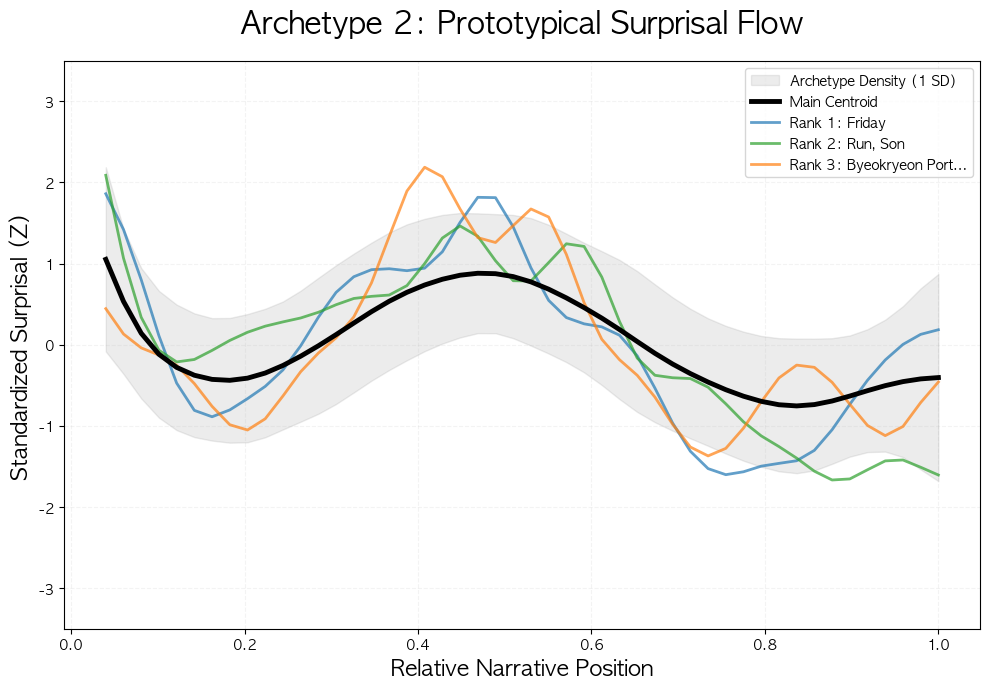


[Archetype 3]
  Rank 1: Our Predestined Autumn (ISBN: 9791187433088)
  Rank 2: Remote Control (ISBN: 9788993632583)
  Rank 3: Short Accompaniment (ISBN: 9788969890337)


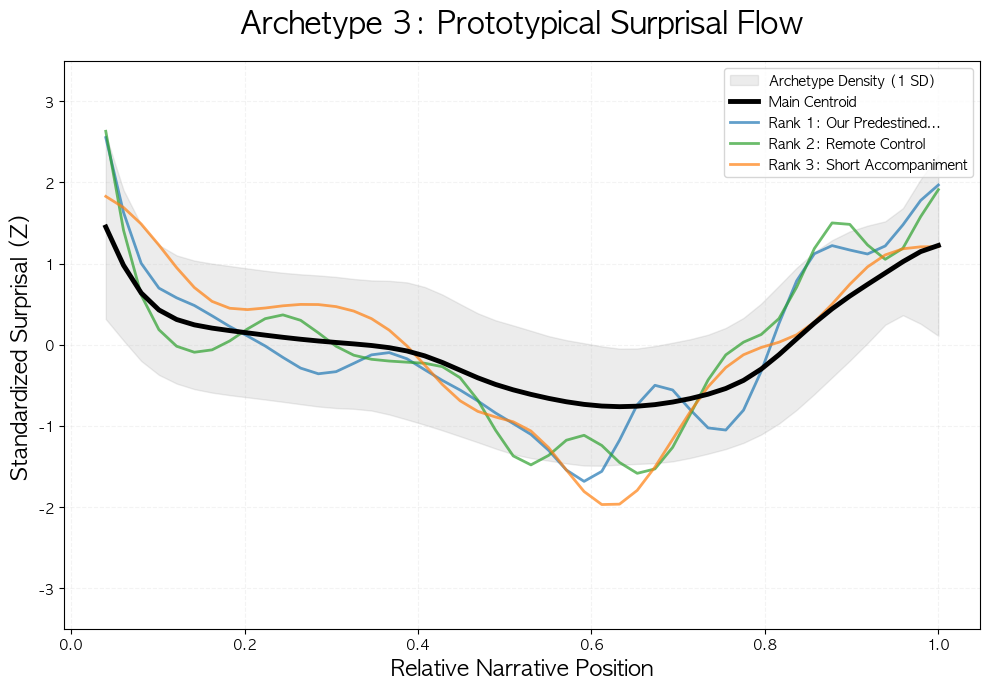


[Archetype 4]
  Rank 1: Realization (ISBN: 9791165699208)
  Rank 2: Lost Beast (ISBN: 9791197114656)
  Rank 3: Because of Sleet (ISBN: 9791130810898)


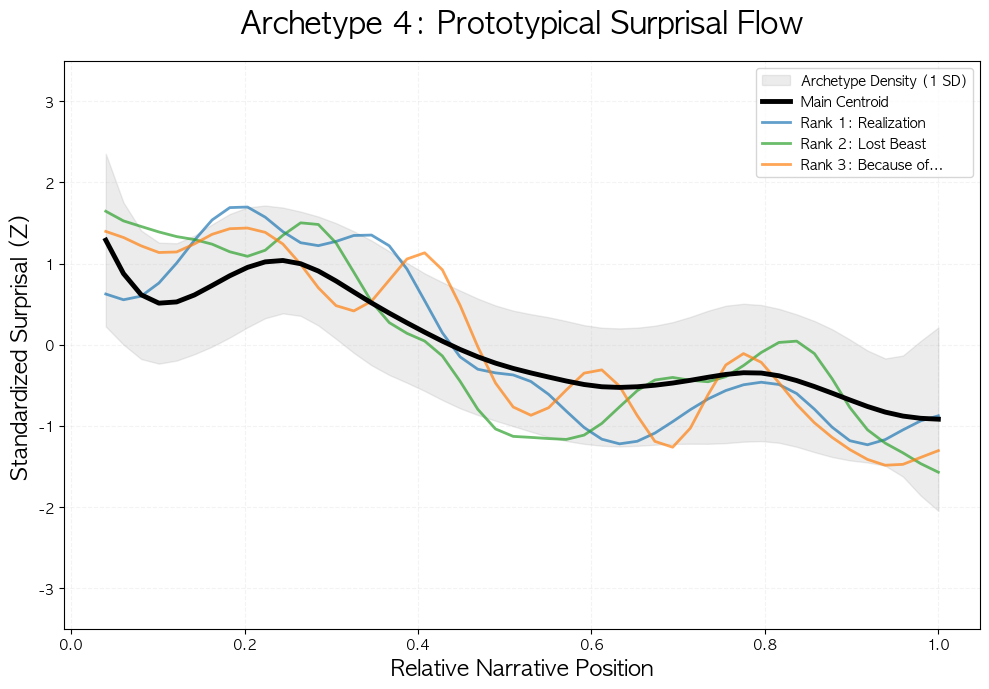


Processing complete. Results saved to: ./surprisal_representative_prototypes.csv


In [30]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.spatial.distance import euclidean
import platform

# ==========================================
# 0. Visualization Setup
# ==========================================
def set_korean_font():
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# ==========================================
# 1. Configuration and Translation Mapping
# ==========================================
base_path = "." 
input_clustered_file = f"{base_path}/short_novel_clustered_surprisal_stable.csv"
output_rep_csv = f"{base_path}/surprisal_representative_prototypes.csv"
output_fig_dir = f"{base_path}/figures"

os.makedirs(output_fig_dir, exist_ok=True)

# English title mapping based on ISBNs
TRANSLATION_MAP = {
    "9791192333014": "Overcoming COVID-44",
    "9791163472896": "Infiltration",
    "9791197603655": "Laughter Injection",
    "9788954629386": "God's Shoes",
    "9791197103803": "Momo-nim",
    "9788960907706": "A Certain Graduation",
    "9791167374462": "Friday",
    "9788960902572": "Run, Son",
    "9791168611092": "Byeokryeon Port...",
    "9791187433088": "Our Predestined Autumn",
    "9788993632583": "Remote Control",
    "9788969890337": "Short Accompaniment",
    "9791165699208": "Realization",
    "9791197114656": "Lost Beast",
    "9791130810898": "Because of Sleet"
}

def safe_vec(x):
    if isinstance(x, list): return x
    try: return list(ast.literal_eval(x))
    except: return []

def get_truncated_title(isbn):
    full_title = TRANSLATION_MAP.get(str(isbn), "Unknown Title")
    words = full_title.split()
    return f"{words[0]} {words[1]}..." if len(words) >= 3 else full_title

# ==========================================
# 2. Main Analysis Logic
# ==========================================
def main():
    print(f"Loading data: {input_clustered_file}")
    df = pd.read_csv(input_clustered_file)
    
    # Parse smoothed curves
    df["vec_s"] = df["surprisal_curve_50_smooth"].apply(safe_vec)
    df = df[df["vec_s"].map(len) == 50].reset_index(drop=True)
    
    # Extract stable region (Bins 2-49) and normalize
    X_raw_full = np.vstack(df["vec_s"].values)
    X_stable = X_raw_full[:, 2:] 
    X_scaled = np.nan_to_num(zscore(X_stable, axis=1))
    
    all_stds = X_scaled.std(axis=1)
    clusters = sorted(df["cluster_surp"].unique())
    rep_list = []
    x_axis = np.linspace(0.04, 1.0, 48)

    print("\n" + "="*50)
    print("Extracting Prototypical Narratives per Archetype")
    print("="*50)

    for k in clusters:
        print(f"\n[Archetype {k}]")
        indices_all = df.index[df["cluster_surp"] == k].tolist()
        cluster_vecs = X_scaled[indices_all]
        
        # Calculate cluster master curve (centroid)
        centroid = cluster_vecs.mean(axis=0)
        std_band = cluster_vecs.std(axis=0) 
        
        # Filtering candidates: Only check for non-zero variance 
        # (Length-based filtering removed due to missing metadata)
        candidate_indices = df.index[
            (df["cluster_surp"] == k) & 
            (all_stds > 1e-5)
        ].tolist()

        if not candidate_indices: continue

        # Rank by Euclidean distance to the centroid
        cluster_distances = sorted([(euclidean(X_scaled[idx], centroid), idx) for idx in candidate_indices])
        top_10 = cluster_distances[:10]

        # --- Visualization ---
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.fill_between(x_axis, centroid - std_band, centroid + std_band, color='gray', alpha=0.15, label='Archetype Density (1 SD)')
        ax.plot(x_axis, centroid, color='black', linewidth=3.5, label='Main Centroid', zorder=10)
        
        colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
        for i, (dist, idx) in enumerate(top_10[:3]):
            row = df.loc[idx]
            isbn_str = str(row['isbn'])
            display_title = get_truncated_title(isbn_str)

            # Peak sentence logic is disabled due to copyright restrictions
            peak_sentence = "Data Restricted" 

            print(f"  Rank {i+1}: {TRANSLATION_MAP.get(isbn_str, 'Unknown')} (ISBN: {isbn_str})")
            ax.plot(x_axis, X_scaled[idx], color=colors[i], alpha=0.7, linewidth=2, label=f"Rank {i+1}: {display_title}")

            rep_list.append({
                "cluster": k, 
                "rank": i + 1, 
                "dist": round(dist, 4),
                "isbn": row['isbn'],
                "title_en": TRANSLATION_MAP.get(isbn_str, "N/A"),
                "peak_sentence": peak_sentence
            })

        ax.set_ylim(-3.5, 3.5)
        ax.set_title(f"Archetype {k}: Prototypical Surprisal Flow", fontsize=22, weight='bold', pad=20)
        ax.set_xlabel("Relative Narrative Position", fontsize=16)
        ax.set_ylabel("Standardized Surprisal (Z)", fontsize=16)
        ax.legend(loc='upper right', fontsize=10, frameon=True)
        ax.grid(True, alpha=0.15, linestyle='--')
        
        plt.tight_layout()
        plt.savefig(f"{output_fig_dir}/cluster_{k}_prototypes.png", dpi=300)
        plt.show()

    # Save summary
    pd.DataFrame(rep_list).to_csv(output_rep_csv, index=False, encoding='utf-8-sig')
    print(f"\nProcessing complete. Results saved to: {output_rep_csv}")

if __name__ == "__main__":
    main()

## 6. Peak-centered Narrative Dynamics: Point-wise Signal Analysis

This section implements a "point-wise acid test" to evaluate the instantaneous systemic response of discourse signals at the exact moment of a narrative shock. By centering our analysis on significant surprisal peaks ($Z > 1.0$), we examine whether these information-theoretic shifts are accompanied by meaningful deviations in coherence and semantic content.

### Statistical Methodology:
1. **Peak Identification:** Significant surprisal peaks are identified within the stable narrative region using a threshold of $Z > 1.0$.
2. **Point-wise Extraction:** For every identified peak, we extract the corresponding $z$-normalized values of **Coherence** and **Semantic Shift**.
3. **One-sample $t$-tests:** We test the aggregated values against the intra-story baseline of zero (the standardized mean). This determines if the signals at peak moments deviate significantly from the story's average.
4. **Multiple Comparison Control:** $P$-values are adjusted using **Bonferroni correction** ($P_{adj} = P_{raw} \times n_{tests}$) to maintain statistical rigour across archetypes and metrics.
5. **Visualization:** Boxplots and stripplots represent the distribution of signal deviations, with significance markers (stars) indicating the strength of the evidence.

> **Data Integrity Note:** This analysis relies on numerical signal vectors derived from the preprocessing stage and does not require raw text access, ensuring compatibility with privacy-restricted datasets.


[INFO] Starting Multi-peak Acid Test (Z > 1.0) analysis...

Archetype    | Metric         | N (Peaks) | Mean(Z)    | T-stat     | Adj. P     | Sig
-----------------------------------------------------------------------------------------------
Archetype 0  | Coherence      | 690      |    -0.1858 |    -5.1584 |   3.26e-06 | ***
Archetype 0  | SemanticShift  | 690      |     0.2059 |     6.0734 |   2.07e-08 | ***
Archetype 1  | Coherence      | 647      |    -0.1205 |    -3.2717 |   1.13e-02 | *
Archetype 1  | SemanticShift  | 647      |     0.3266 |     8.3135 |   5.49e-15 | ***
Archetype 2  | Coherence      | 686      |    -0.1620 |    -4.9159 |   1.11e-05 | ***
Archetype 2  | SemanticShift  | 686      |     0.2152 |     6.1542 |   1.28e-08 | ***
Archetype 3  | Coherence      | 711      |    -0.1608 |    -4.6345 |   4.26e-05 | ***
Archetype 3  | SemanticShift  | 711      |     0.3141 |     8.3672 |   3.13e-15 | ***
Archetype 4  | Coherence      | 886      |    -0.0664 |    -2.0883 |  

/var/folders/17/8f0ydqmd0vb_k2j226w720g00000gn/T/ipykernel_69751/2643260732.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Archetype", y="Value", palette=color_map, showfliers=True)


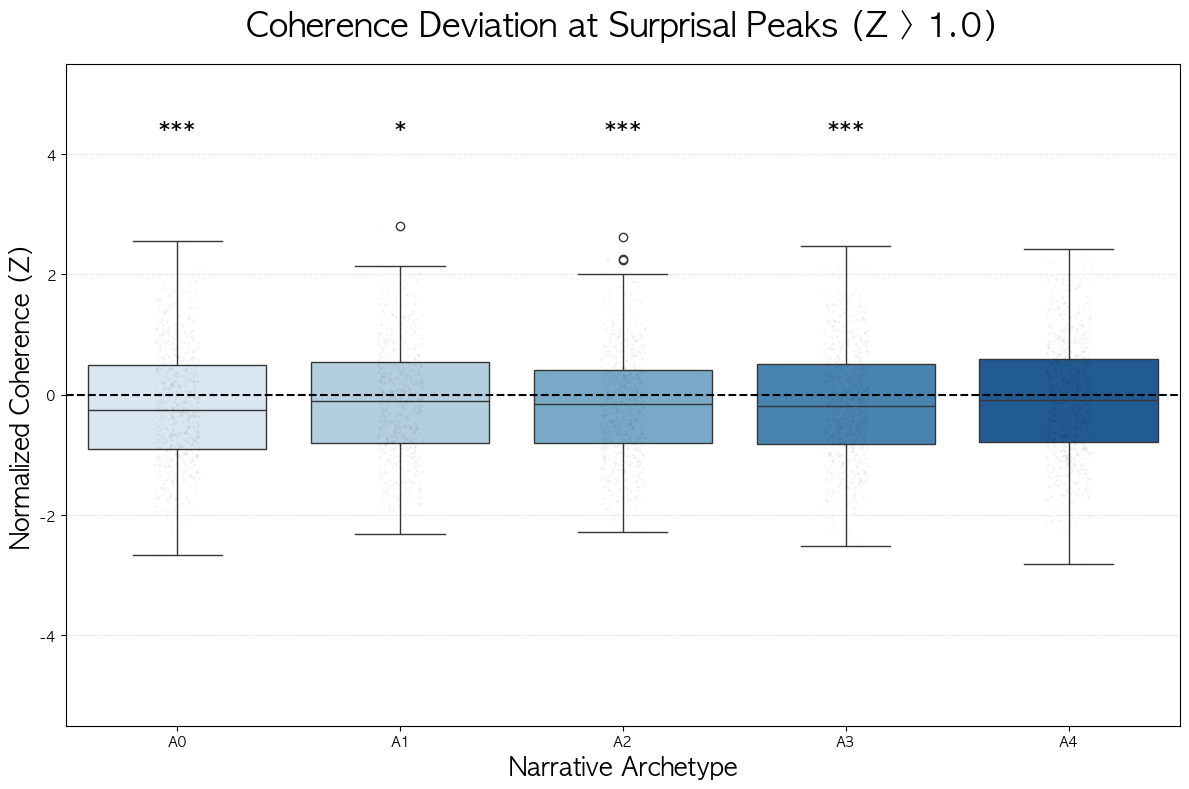

/var/folders/17/8f0ydqmd0vb_k2j226w720g00000gn/T/ipykernel_69751/2643260732.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="Archetype", y="Value", palette=color_map, showfliers=True)


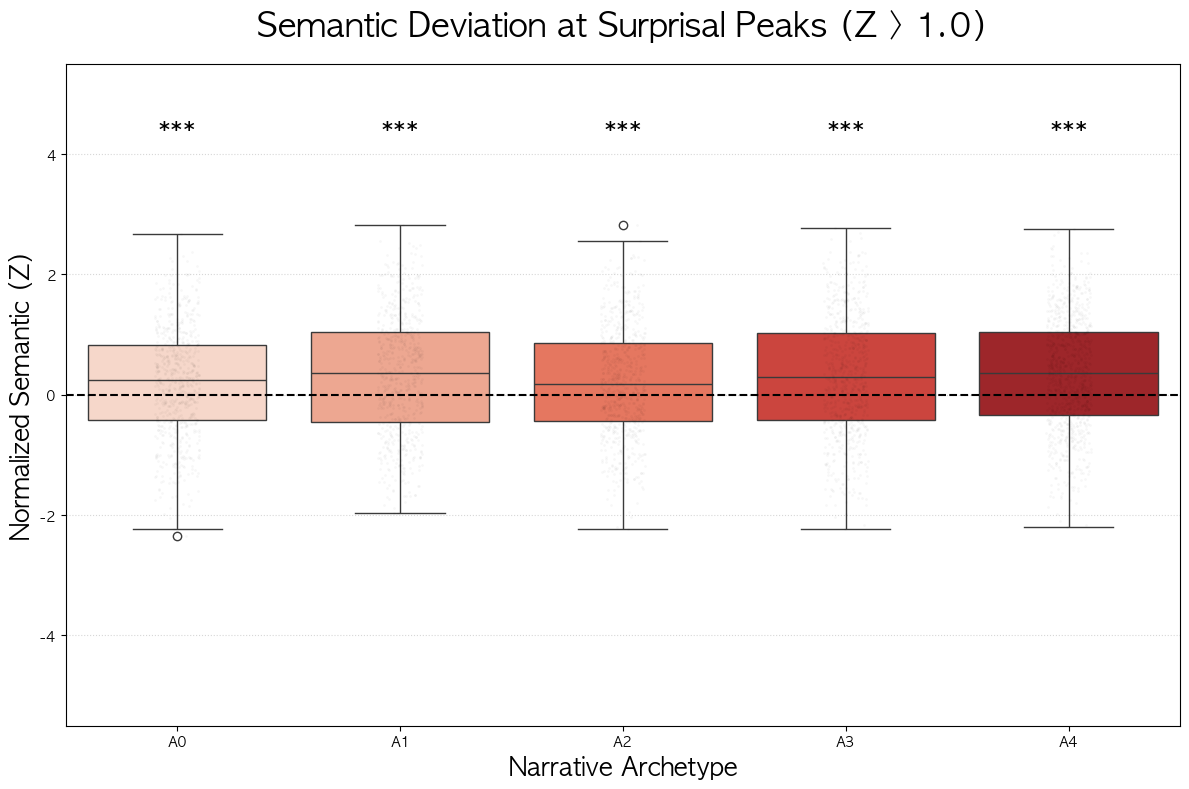

In [35]:
import os
import pandas as pd
import numpy as np
import ast
from scipy.stats import ttest_1samp
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# ==========================================
# 0. Environment Setup
# ==========================================
def set_korean_font():
    """Configures fonts for plotting based on the operating system."""
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

BASE_PATH = "." 
FEAT_FILE = f"{BASE_PATH}/short_novel_with_all_features_50.csv"
CLUST_FILE = f"{BASE_PATH}/short_novel_clustered_surprisal_stable.csv"
OUTPUT_DIR = f"{BASE_PATH}/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RESULT_OUT = os.path.join(BASE_PATH, "peak_statistical_results.csv")
# ==========================================
# 1. Utility Functions
# ==========================================
def safe_vec(x):
    """Safely parses string-encoded list representations."""
    if isinstance(x, list): return x
    try: return ast.literal_eval(x)
    except: return []

def get_z_score_stable(vec):
    """
    Applies Z-score normalization based exclusively on the stable region (Bins 2-49).
    This ensures that initialization noise (burn-in) does not bias the mean or variance.
    """
    arr = np.array(vec)
    stable_region = arr[2:] 
    mu, sigma = np.mean(stable_region), np.std(stable_region)
    return (arr - mu) / sigma if sigma != 0 else np.zeros_like(arr)

def get_star(p):
    """Returns significance markers based on adjusted p-values."""
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    return "n.s."

# ==========================================
# 2. Main Analysis: Point-wise T-tests
# ==========================================
def main():
    print(f"\n[INFO] Starting Multi-peak Acid Test (Z > 1.0) analysis...")
    
    # Load feature and cluster data
    df_feat = pd.read_csv(FEAT_FILE)
    df_clust = pd.read_csv(CLUST_FILE)

    # Parse smoothed curves for all three narrative signals
    df_feat["s_curve"] = df_feat["surprisal_curve_50_smooth"].apply(safe_vec)
    df_feat["c_curve"] = df_feat["coherence_curve_50_smooth"].apply(safe_vec)
    df_feat["m_curve"] = df_feat["semantic_shift_curve_50_smooth"].apply(safe_vec)

    # Align cluster labels with valid narrative data
    df_valid = df_feat[df_feat["s_curve"].map(len) == 50].reset_index(drop=True)
    df_valid["cluster"] = df_clust["cluster_surp"].values

    clusters = sorted(df_valid["cluster"].unique())
    # Bonferroni correction factor: (Clusters x Metrics)
    num_tests = len(clusters) * 2 
    
    records_coh, records_sem, stats_list = [], [], []

    print("\n" + "="*95)
    print(f"{'Archetype':<12} | {'Metric':<14} | {'N (Peaks)':<8} | {'Mean(Z)':<10} | {'T-stat':<10} | {'Adj. P':<10} | {'Sig'}")
    print("-" * 95)

    for k in clusters:
        sub_df = df_valid[df_valid["cluster"] == k]
        vals_c, vals_m = [], []
        
        for _, row in sub_df.iterrows():
            # Standardize signals within each story's stable regime
            s_norm = get_z_score_stable(row["s_curve"])
            c_norm = get_z_score_stable(row["c_curve"])
            m_norm = get_z_score_stable(row["m_curve"])
            
            # Find local maxima in surprisal curve exceeding Z > 1.0 threshold
            peaks, _ = find_peaks(s_norm[2:], height=1.0)
            actual_peaks = peaks + 2 # Re-align to original bin indices
            
            for p_idx in actual_peaks:
                vals_c.append(c_norm[p_idx])
                vals_m.append(m_norm[p_idx])
                records_coh.append({"Archetype": f"A{k}", "Value": c_norm[p_idx]})
                records_sem.append({"Archetype": f"A{k}", "Value": m_norm[p_idx]})

        # Perform statistical testing for each metric
        for metric_name, values in [("Coherence", vals_c), ("SemanticShift", vals_m)]:
            # One-sample T-test against the baseline mean of 0
            t_stat, p_raw = ttest_1samp(values, 0, nan_policy='omit')
            p_adj = min(p_raw * num_tests, 1.0) # Apply Bonferroni correction
            mean_val = np.mean(values)
            std_err = np.std(values) / np.sqrt(len(values))
            
            stats_list.append({
                "Archetype": f"Archetype {k}", "Metric": metric_name, "N_Peaks": len(values),
                "Mean": round(mean_val, 4), "StdError": round(std_err, 4),
                "T_Statistic": round(t_stat, 4), "P_Adj": f"{p_adj:.3e}",
                "Significance": get_star(p_adj)
            })

            print(f"Archetype {k:<2} | {metric_name:<14} | {len(values):<8} | {mean_val:>10.4f} | {t_stat:>10.4f} | {p_adj:>10.2e} | {get_star(p_adj)}")

    # Save detailed statistical results
    result_df = pd.DataFrame(stats_list)
    result_df.to_csv(RESULT_OUT, index=False, encoding="utf-8-sig")    

    # ==========================================
    # 3. Visualization: Signal Deviations at Peaks
    # ==========================================
    for metric, data_list, color_map in [
        ("Coherence", records_coh, "Blues"),
        ("Semantic", records_sem, "Reds")
    ]:
        
        plt.figure(figsize=(12, 8))
        df_plot = pd.DataFrame(data_list)
        
        # Plot distributions using Boxplot + Stripplot for transparency
        sns.boxplot(data=df_plot, x="Archetype", y="Value", palette=color_map, showfliers=True)
        sns.stripplot(data=df_plot, x="Archetype", y="Value", color="black", alpha=0.03, size=2)
        plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
        
        # Annotate significant archetypes with stars
        for i, k in enumerate(clusters):
            row = result_df[(result_df["Archetype"] == f"Archetype {k}") & (result_df["Metric"].str.contains(metric))]
            if not row.empty:
                star = row.iloc[0]["Significance"]
                if star != "n.s.":
                    plt.text(i, 4.2, star, ha='center', fontsize=20, fontweight='bold')

        plt.title(f"{metric} Deviation at Surprisal Peaks (Z > 1.0)", fontsize=24, pad=20)
        plt.ylabel(f"Normalized {metric} (Z)", fontsize=18)
        plt.xlabel("Narrative Archetype", fontsize=18)
        plt.ylim(-5.5, 5.5)
        plt.grid(True, axis='y', linestyle=':', alpha=0.5)
        
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/peak_dynamics_{metric.lower()}.png", dpi=300)
        plt.show()

if __name__ == "__main__":
    main()

## 7. Event-locked Dynamic Recovery Analysis: Narrative Resilience

This section quantifies the **structural elasticity** of each narrative archetype by analyzing how discourse signals (Coherence and Semantic Shift) recover following a surprisal shock ($Z > 1.0$). We operationalize narrative resilience through two primary metrics:

1. **Time-to-Recovery (TTR):** The number of bins required for a signal to return to the story-specific baseline ($Z=0$).
2. **Dynamic Recovery Slope ($S_{rec}$):** The average rate of change from the peak/trough back to the baseline, representing the intensity of the corrective narrative adjustment.

### Statistical Framework:
- **Event-segmentation:** Each significant peak is treated as a discrete event boundary.
- **Resilience Comparison:** We use **One-way ANOVA** to test for global differences between archetypes.
- **Post-hoc Analysis:** **Tukey HSD** is performed to identify specific pairs of archetypes that exhibit significantly different recovery mechanics (e.g., rapid resilience vs. lingering reorientation).

$$\mathrm{TTR} = t_{\mathrm{rec}} - t_0$$
$$S_{\mathrm{rec}} = \frac{V(t_{\mathrm{rec}}) - V(t_0)}{t_{\mathrm{rec}} - t_0}$$

[INFO] Initializing Event-locked Integrated Dynamic Analysis...

[ANALYSIS] Metric: Coherence Recovery Time (TTR)
--------------------------------------------------
ANOVA Results -> F-statistic: 2.9920, p-value: 1.7905e-02
Significant difference found. Performing Tukey HSD...
     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
Archetype 0 Archetype 1   0.2265 0.8154 -0.3446  0.7975  False
Archetype 0 Archetype 2   0.1236 0.9747 -0.4369  0.6841  False
Archetype 0 Archetype 3  -0.4377 0.2209 -1.0072  0.1318  False
Archetype 0 Archetype 4  -0.0557 0.9986 -0.5893  0.4779  False
Archetype 1 Archetype 2  -0.1028 0.9872 -0.6628  0.4571  False
Archetype 1 Archetype 3  -0.6642 0.0127 -1.2331 -0.0952   True
Archetype 1 Archetype 4  -0.2822 0.5981 -0.8152  0.2509  False
Archetype 2 Archetype 3  -0.5613  0.048 -1.1196  -0.003   True
Archetype 2 Archetype 4  -0.17

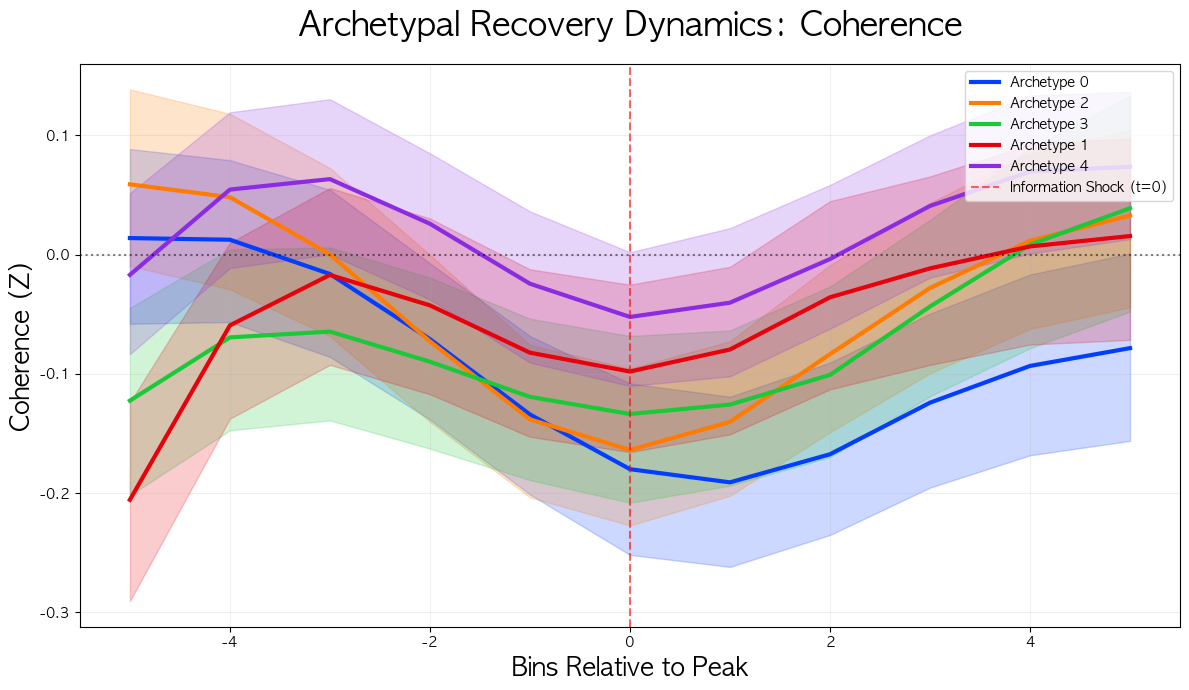

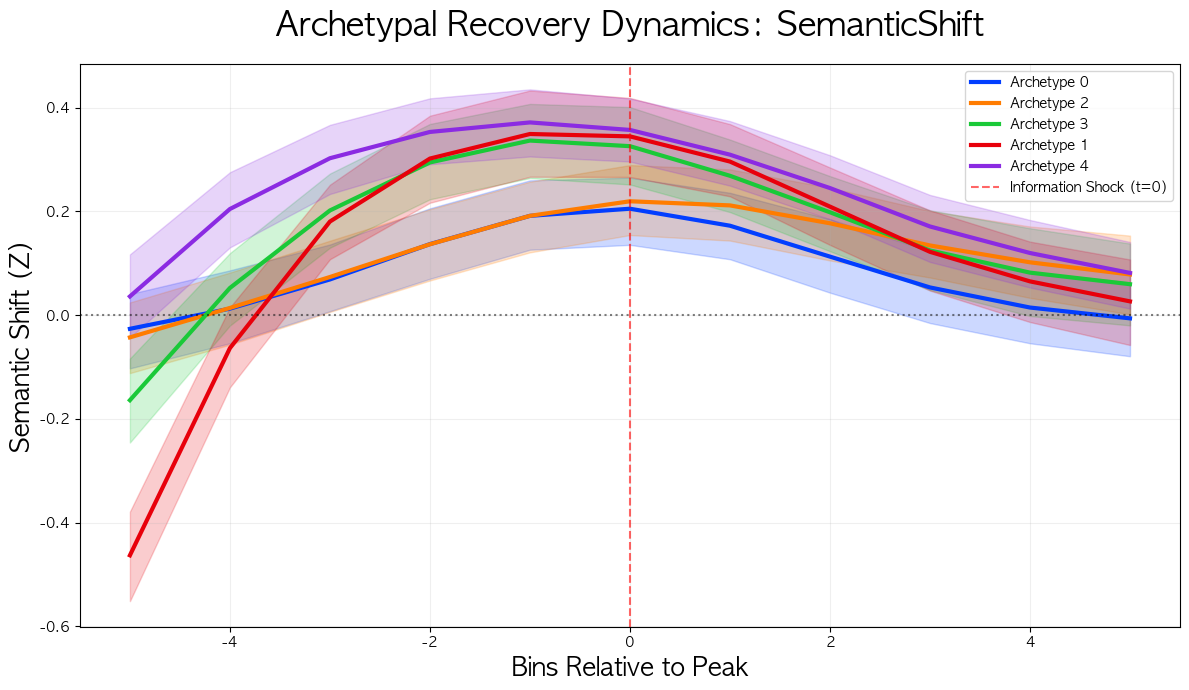


[SUCCESS] Statistical report saved to: ./recovery_statistical_report.txt


In [34]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from scipy.signal import find_peaks
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import platform

# ==========================================
# 0. Environment Setup
# ==========================================
def set_korean_font():
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

BASE_PATH = "." 
FEAT_FILE = f"{BASE_PATH}/short_novel_with_all_features_50.csv"
CLUST_FILE = f"{BASE_PATH}/short_novel_clustered_surprisal_stable.csv"
SAVE_DIR = os.path.join(BASE_PATH, "figures")
os.makedirs(SAVE_DIR, exist_ok=True)

# Path for the detailed statistical report
STATS_OUT = os.path.join(BASE_PATH, "recovery_statistical_report.txt")
SEARCH_WINDOW = 10  # Omega window for recovery observation
TITLE_SIZE, LABEL_SIZE = 24, 18

# ==========================================
# 1. Utility Functions
# ==========================================
def safe_vec(x):
    try: return list(ast.literal_eval(x))
    except: return []

def get_z_norm_stable(vec):
    """Normalize based on stable region (Bins 2-49) to remove burn-in bias."""
    arr = np.array(vec)[2:] 
    if len(arr) < 2 or np.std(arr) == 0: return np.zeros_like(arr)
    return (arr - np.mean(arr)) / np.std(arr)

def calculate_dynamic_recovery(post_peak_series, metric_type="coherence"):
    """
    Computes Time-to-Recovery (TTR) and Recovery Slope.
    TTR: Time steps to reach Z=0 baseline.
    Slope: Rate of recovery per time step.
    """
    ttr, slope = np.nan, np.nan
    if len(post_peak_series) <= 1: return ttr, slope
    peak_val = post_peak_series[0]
    
    for i in range(1, len(post_peak_series)):
        current_val = post_peak_series[i]
        if np.isnan(current_val): break
        
        # Coherence: recovering UP from a trough; Semantic Shift: recovering DOWN from a peak
        recovered = (peak_val < 0 and current_val >= 0) if metric_type == "coherence" else (peak_val > 0 and current_val <= 0)
        
        if recovered:
            ttr = i
            slope = (current_val - peak_val) / i
            break
    return ttr, slope

# ==========================================
# 2. Main Analysis Pipeline
# ==========================================
def main():
    print(f"[INFO] Initializing Event-locked Integrated Dynamic Analysis...")
    df_feat = pd.read_csv(FEAT_FILE)
    df_clust = pd.read_csv(CLUST_FILE)
    df_feat["cluster"] = df_clust["cluster_surp"].values

    analysis_results = []
    plot_data = []

    for _, row in df_feat.iterrows():
        s_vec = safe_vec(row["surprisal_curve_50_smooth"])
        c_vec = safe_vec(row["coherence_curve_50_smooth"])
        m_vec = safe_vec(row["semantic_shift_curve_50_smooth"])
        
        if len(s_vec) < 10: continue
        
        s_z = get_z_norm_stable(s_vec)
        c_z = get_z_norm_stable(c_vec)
        m_z = get_z_norm_stable(m_vec)

        # Detect all shocks with Surprisal Z > 1.0
        peaks, _ = find_peaks(s_z, height=PEAK_THRESHOLD)
        
        for p_idx in peaks:
            # Recovery calculation
            post_c = c_z[p_idx : p_idx + SEARCH_WINDOW]
            post_m = m_z[p_idx : p_idx + SEARCH_WINDOW]
            
            ttr_c, slope_c = calculate_dynamic_recovery(post_c, "coherence")
            ttr_m, slope_m = calculate_dynamic_recovery(post_m, "semantic_shift")
            
            analysis_results.append({
                "Cluster": f"Archetype {row['cluster']}",
                "TTR_C": ttr_c, "Slope_C": slope_c, 
                "TTR_M": ttr_m, "Slope_M": slope_m
            })
            
            # Data for dynamic evolution plotting
            start, end = max(0, p_idx - 5), min(len(c_z), p_idx + 6)
            for t_rel, idx in enumerate(range(start, end), -5):
                if 0 <= idx < len(c_z):
                    plot_data.append({
                        "Cluster": f"Archetype {row['cluster']}",
                        "Time": t_rel, "Coherence": c_z[idx], "SemanticShift": m_z[idx]
                    })

    df_res = pd.DataFrame(analysis_results)
    df_plot = pd.DataFrame(plot_data)

    # ==========================================
    # 3. STATISTICAL REPORTING (ANOVA & Tukey HSD)
    # ==========================================
    with open(STATS_OUT, "w", encoding="utf-8") as f:
        f.write("=== MULTI-PEAK DYNAMIC RECOVERY STATISTICAL REPORT ===\n\n")
        
        target_metrics = [
            ("TTR_C", "Coherence Recovery Time (TTR)"), 
            ("Slope_C", "Coherence Recovery Slope"),
            ("TTR_M", "Semantic Shift Recovery Time (TTR)"), 
            ("Slope_M", "Semantic Shift Recovery Slope")
        ]
        
        for col, name in target_metrics:
            sub_df = df_res.dropna(subset=[col])
            
            # Print Metric Header
            line = f"\n[ANALYSIS] Metric: {name}\n" + "-"*50
            print(line); f.write(line + "\n")
            
            # Global ANOVA
            groups = [sub_df[sub_df["Cluster"] == f"Archetype {i}"][col] for i in range(len(df_feat["cluster"].unique()))]
            valid_groups = [g for g in groups if len(g) > 1]
            
            if len(valid_groups) >= 2:
                f_stat, p_val = f_oneway(*valid_groups)
                res_msg = f"ANOVA Results -> F-statistic: {f_stat:.4f}, p-value: {p_val:.4e}"
                print(res_msg); f.write(res_msg + "\n")
                
                # Tukey HSD Post-hoc
                if p_val < 0.05:
                    print(f"Significant difference found. Performing Tukey HSD...")
                    tukey = pairwise_tukeyhsd(sub_df[col], sub_df['Cluster'], alpha=0.05)
                    print(tukey); f.write("\n[Tukey HSD Results]\n" + str(tukey) + "\n")
            else:
                msg = "Insufficient data for ANOVA."
                print(msg); f.write(msg + "\n")

    # ==========================================
    # 4. Visualization: Recovery Trajectories
    # ==========================================
    
    for metric, ylabel in [("Coherence", "Coherence (Z)"), ("SemanticShift", "Semantic Shift (Z)")]:
        plt.figure(figsize=(12, 7))
        sns.lineplot(data=df_plot, x="Time", y=metric, hue="Cluster", palette="bright", linewidth=3, errorbar=('ci', 95))
        plt.axvline(0, color='red', linestyle='--', alpha=0.6, label='Information Shock (t=0)')
        plt.axhline(0, color='black', linestyle=':', alpha=0.5)
        plt.title(f"Archetypal Recovery Dynamics: {metric}", fontsize=TITLE_SIZE, pad=20)
        plt.xlabel("Bins Relative to Peak", fontsize=LABEL_SIZE)
        plt.ylabel(ylabel, fontsize=LABEL_SIZE)
        plt.legend(loc='upper right', frameon=True)
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, f"recovery_dynamics_{metric.lower()}.png"), dpi=300)
        plt.show()

    print(f"\n[SUCCESS] Statistical report saved to: {STATS_OUT}")

if __name__ == "__main__":
    main()

## 8. Bonus Analysis: Meso-scale Narrative Dynamics

This additional analysis visualizes the **local temporal trajectories** of Coherence and Semantic Shift surrounding surprisal shocks. Instead of looking at a single point, we extract a window of $\pm5$ bins around every significant peak ($Z > 1.0$) to capture the "meso-scale" rhythmic patterns of each archetype.

### Key Features:
1. **Window Extraction:** For every detected shock, the script captures the surrounding context to see how signals behave *immediately before* and *immediately after* the event.
2. **Aggregated Flow:** By averaging these segments across the entire cluster, we produce a robust representation of the "typical" narrative movement for each archetype.
3. **Multi-peak Inclusion:** All valid shocks within a story are included, providing a comprehensive view of the structural dynamics across the corpus.
4. **Visual Interpretation:** - **Coherence (Blue):** Often shows a "trough" or dip at the moment of shock.
    - **Semantic Shift (Red):** Often shows a "peak" or surge as the narrative jumps to new thematic content.

Loading data and initializing meso-scale analysis...
Archetype 0: Plot saved (Shocks Analyzed: 554)


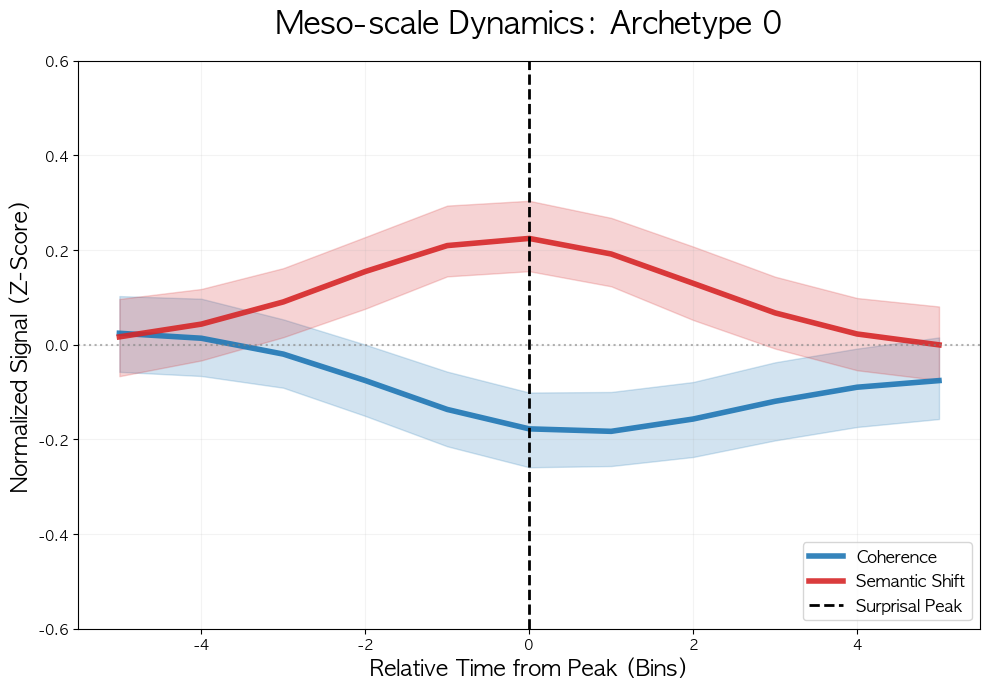

Archetype 1: Plot saved (Shocks Analyzed: 476)


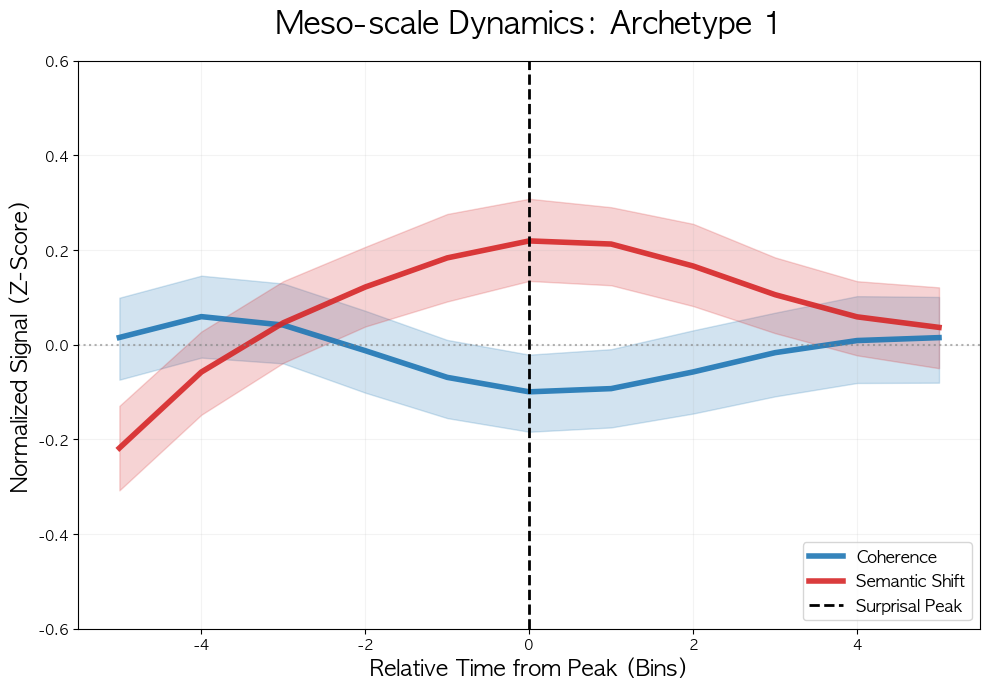

Archetype 2: Plot saved (Shocks Analyzed: 571)


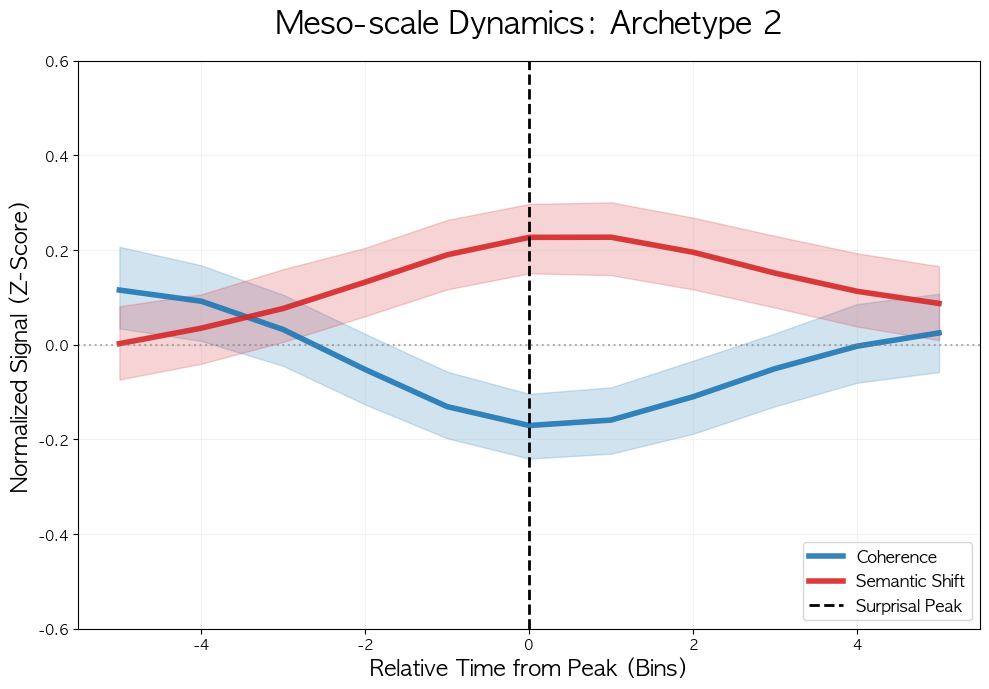

Archetype 3: Plot saved (Shocks Analyzed: 490)


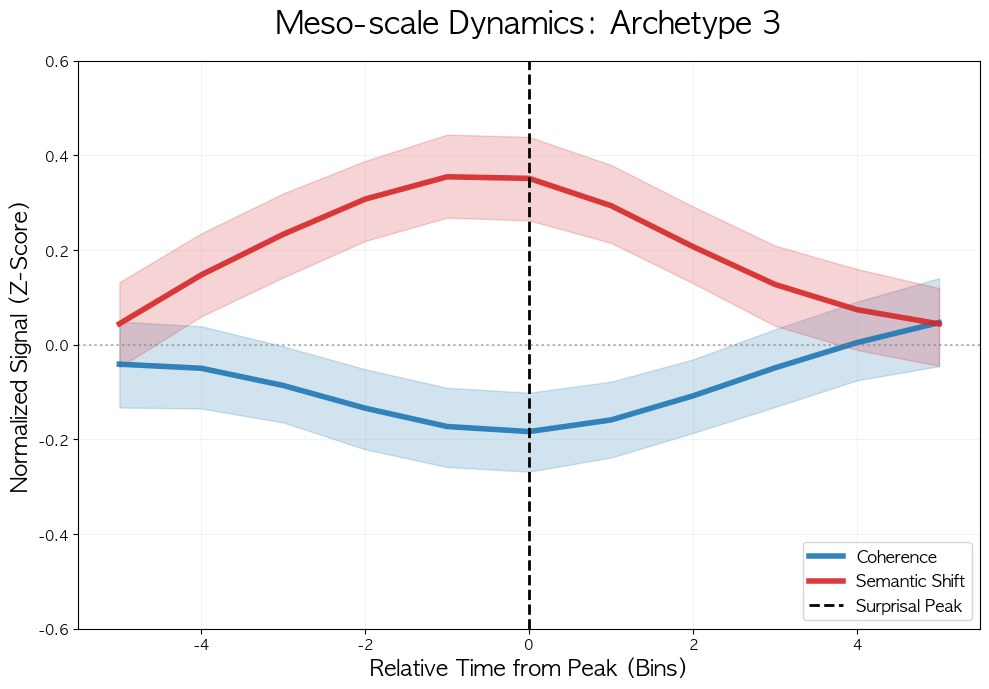

Archetype 4: Plot saved (Shocks Analyzed: 744)


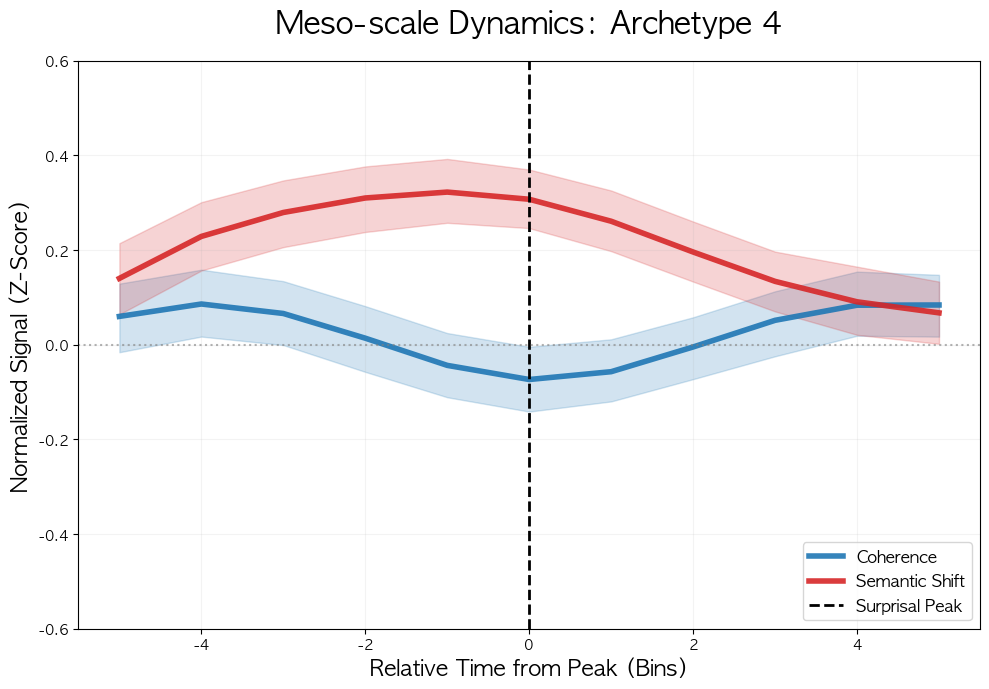

In [33]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.signal import find_peaks
import platform

# ==========================================
# 0. Environment Setup
# ==========================================
def set_korean_font():
    """Sets appropriate fonts based on the operating system."""
    system = platform.system()
    if system == "Darwin": plt.rc('font', family='AppleGothic')
    elif system == "Windows": plt.rc('font', family='Malgun Gothic')
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# Path and Parameter Configuration
base_path = "."
feat_file = f"{base_path}/short_novel_with_all_features_50.csv"
clust_file = f"{base_path}/short_novel_clustered_surprisal_stable.csv"
output_folder = f"{base_path}/figures"
os.makedirs(output_folder, exist_ok=True)

WINDOW_SIZE = 5      # Number of bins to extract before and after the peak
PEAK_THRESHOLD = 1.0 # Z-score threshold for identifying a shock
MIN_PEAK_DIST = 10   # Minimum distance between peaks to avoid overlapping windows

def safe_vec(x):
    """Safely parses string-encoded list representations."""
    if isinstance(x, list): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return []
    return []

def get_z_norm_stable(vec):
    """Applies Z-score normalization based on the stable region (excluding burn-in)."""
    arr = np.array(vec)
    stable_region = arr[2:] 
    mu = np.mean(stable_region)
    sigma = np.std(stable_region)
    if sigma == 0: return arr * 0
    return (arr - mu) / sigma

def main():
    print("Loading data and initializing meso-scale analysis...")
    df_feat = pd.read_csv(feat_file)
    df_clust = pd.read_csv(clust_file)

    # Convert curve strings to numerical lists
    df_feat["s_curve"] = df_feat["surprisal_curve_50_smooth"].apply(safe_vec)
    df_feat["c_curve"] = df_feat["coherence_curve_50_smooth"].apply(safe_vec)
    df_feat["m_curve"] = df_feat["semantic_shift_curve_50_smooth"].apply(safe_vec)
    
    # Align cluster labels
    df_valid = df_feat[df_feat["s_curve"].map(len) == 50].reset_index(drop=True)
    df_valid["cluster"] = df_clust["cluster_surp"].values
    
    all_segments = []
    filtering_stats = []

    # ==========================================
    # 1. Segment Extraction (Multi-peak Analysis)
    # ==========================================
    for k in sorted(df_valid["cluster"].unique()):
        sub_df = df_valid[df_valid["cluster"] == k]
        total_novels = len(sub_df)
        peak_count = 0
        
        for _, row in sub_df.iterrows():
            # Standardize signals locally
            s_norm = get_z_norm_stable(row["s_curve"])
            c_norm = get_z_norm_stable(row["c_curve"])
            m_norm = get_z_norm_stable(row["m_curve"])
            
            # Detect all significant local maxima in surprisal
            peaks, _ = find_peaks(s_norm[2:], height=PEAK_THRESHOLD, distance=MIN_PEAK_DIST)
            peaks = peaks + 2 # Offset correction
            
            for peak_idx in peaks:
                start, end = peak_idx - WINDOW_SIZE, peak_idx + WINDOW_SIZE + 1
                # Ensure the window stays within the 50-bin boundary
                if start < 2 or end > 50: continue
                
                peak_count += 1
                c_seg = c_norm[start:end]
                m_seg = m_norm[start:end]
                x_axis = np.arange(-WINDOW_SIZE, WINDOW_SIZE + 1)
                
                # Store relative time steps for aggregation
                for t, cv, mv in zip(x_axis, c_seg, m_seg):
                    all_segments.append({
                        "Cluster": k, "Time": t, "Coherence": cv, "Semantic Shift": mv
                    })
        
        filtering_stats.append({"Cluster": k, "Total_Novels": total_novels, "Found_Peaks": peak_count})

    df_plot_all = pd.DataFrame(all_segments)

    # ==========================================
    # 2. Archetype-specific Visualization
    # ==========================================
    for k in sorted(df_plot_all["Cluster"].unique()):
        sub_plot = df_plot_all[df_plot_all["Cluster"] == k]
        if sub_plot.empty: continue

        # Melt data for Seaborn hue-based plotting
        melted = sub_plot.melt(id_vars=["Time"], value_vars=["Coherence", "Semantic Shift"], 
                               var_name="Type", value_name="Value")

        
        fig, ax = plt.subplots(figsize=(10, 7))
        sns.lineplot(
            data=melted, x="Time", y="Value", hue="Type", 
            palette={"Coherence": "tab:blue", "Semantic Shift": "tab:red"},
            linewidth=4, errorbar=('ci', 95), alpha=0.9, ax=ax
        )
        
        # Plot Styling
        ax.set_ylim(-0.6, 0.6)
        ax.set_yticks(np.arange(-0.6, 0.7, 0.2))
        ax.set_title(f"Meso-scale Dynamics: Archetype {k}", 
                     fontsize=22, fontweight='bold', pad=20)
        ax.set_xlabel("Relative Time from Peak (Bins)", fontsize=16)
        ax.set_ylabel("Normalized Signal (Z-Score)", fontsize=16)
        
        # Reference lines
        ax.axvline(0, color='black', linestyle='--', linewidth=2, label="Surprisal Peak")
        ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
        ax.legend(loc='lower right', fontsize=12)
        ax.grid(True, alpha=0.15)
        
        plt.tight_layout()
        out_path = f"{output_folder}/archetype_{k}_meso_dynamics.png"
        plt.savefig(out_path, dpi=300)
        print(f"Archetype {k}: Plot saved (Shocks Analyzed: {filtering_stats[k]['Found_Peaks']})")
        plt.show()

if __name__ == "__main__":
    main()